<a href="https://colab.research.google.com/github/sradha8658/HealthCare-Analytics-Project/blob/main/HealthCare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Upload Dataset

In [2]:
import numpy as np
import pandas as pd
df=pd.read_excel("/content/drive/MyDrive/Sradha/Health Analytics projects.xlsx")

2.Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

3.Load Dataset

In [4]:
df = pd.read_excel("/content/drive/MyDrive/Sradha/Health Analytics projects.xlsx")

df.head()

,patient_id,age,gender,race,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,glucose_level,blood_pressure,bmi,insulin,diabetes_medication,hypertension,heart_disease,smoker,length_since_diagnosis_years,readmitted_30_days
0,100000,69,Male,Other,3,103,1,4,14,1,...,209,128,32.5,Down,No,No,Yes,Yes,6,1
1,100001,32,Male,Other,5,43,6,24,8,1,...,78,146,25.5,Steady,No,Yes,Yes,No,27,0
2,100002,89,Female,Black,10,49,7,7,11,4,...,198,104,20.5,Up,Yes,No,No,No,16,1
3,100003,78,Male,Black,7,5,0,24,6,5,...,121,164,39.6,Down,Yes,No,Yes,Yes,16,1
4,100004,38,Female,Asian,7,1,7,11,13,2,...,240,143,24.0,Up,Yes,Yes,No,No,24,0


4.check row and column

In [5]:
df.shape

(10000, 24)

5.Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    10000 non-null  int64  
 1   age                           10000 non-null  int64  
 2   gender                        10000 non-null  object 
 3   race                          10000 non-null  object 
 4   time_in_hospital              10000 non-null  int64  
 5   num_lab_procedures            10000 non-null  int64  
 6   num_procedures                10000 non-null  int64  
 7   num_medications               10000 non-null  int64  
 8   number_outpatient             10000 non-null  int64  
 9   number_emergency              10000 non-null  int64  
 10  number_inpatient              10000 non-null  int64  
 11  number_diagnoses              10000 non-null  int64  
 12  previous_admissions           10000 non-null  int64  
 13  A1

In [7]:
df.describe()

,patient_id,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,previous_admissions,glucose_level,blood_pressure,bmi,length_since_diagnosis_years,readmitted_30_days
count,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,104999.50000,53.539700,7.57920,60.056600,3.502400,24.872800,6.972200,4.490600,4.565400,5.972100,5.491500,183.740800,129.716000,31.53939,14.507100,0.679600
std,2886.89568,20.757324,3.99819,34.203725,2.287645,14.154874,4.294121,2.876376,2.900132,3.165553,3.459122,66.468414,28.944781,7.77882,8.656018,0.466654
min,100000.00000,18.000000,1.00000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,70.000000,80.000000,18.00000,0.000000,0.000000
25%,102499.75000,36.000000,4.00000,30.000000,1.000000,13.000000,3.000000,2.000000,2.000000,3.000000,2.000000,126.000000,104.000000,24.80000,7.000000,0.000000
50%,104999.50000,53.000000,8.00000,60.000000,3.000000,25.000000,7.000000,4.000000,5.000000,6.000000,6.000000,183.000000,129.000000,31.60000,15.000000,1.000000
75%,107499.25000,72.000000,11.00000,90.000000,6.000000,37.000000,11.000000,7.000000,7.000000,9.000000,8.000000,242.000000,155.000000,38.20000,22.000000,1.000000
max,109999.00000,89.000000,14.00000,119.000000,7.000000,49.000000,14.000000,9.000000,9.000000,11.000000,11.000000,299.000000,179.000000,45.00000,29.000000,1.000000


In [8]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
race,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0
number_outpatient,0
number_emergency,0


6.Exploratory Data Analysis (EDA)
Readmission Distribution

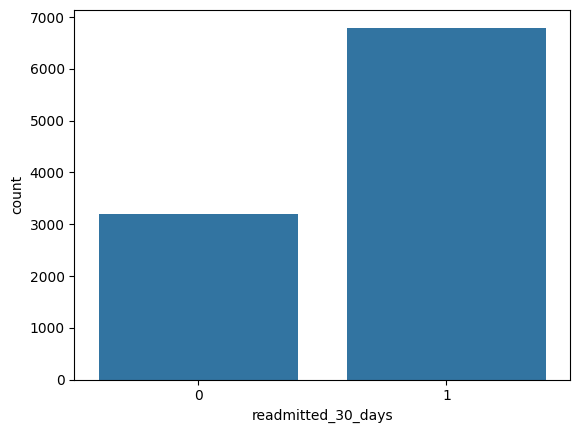

In [10]:
sns.countplot(
    x='readmitted_30_days',
    data=df
)

plt.show()

7.Age Distribution

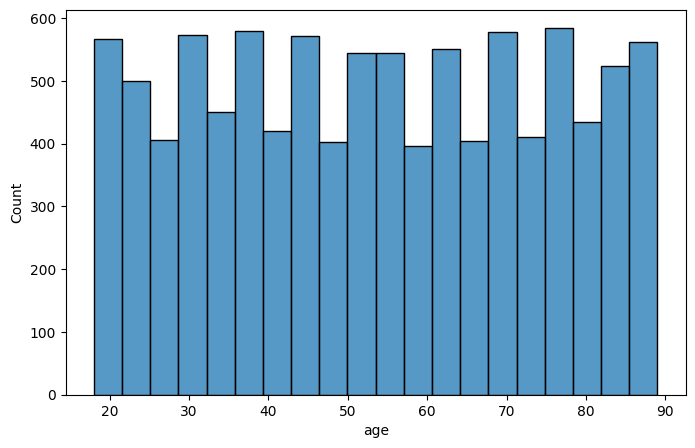

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=20
)

plt.show()

8.Glucose Level Distribution

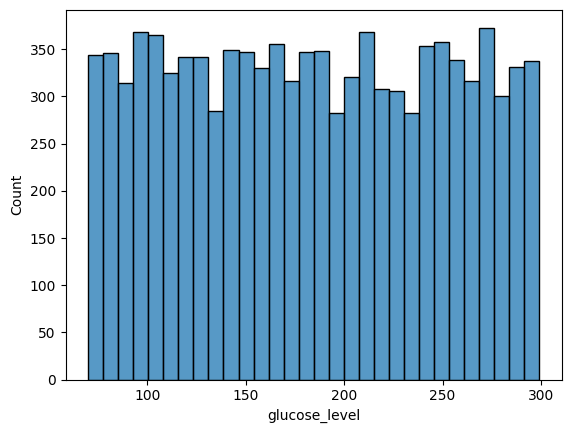

In [12]:
sns.histplot(
    df['glucose_level'],
    bins=30
)

plt.show()

9.Correlation Analysis

Convert categorical variables.

In [15]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(
            df[col]
        )

Correlation heatmap:

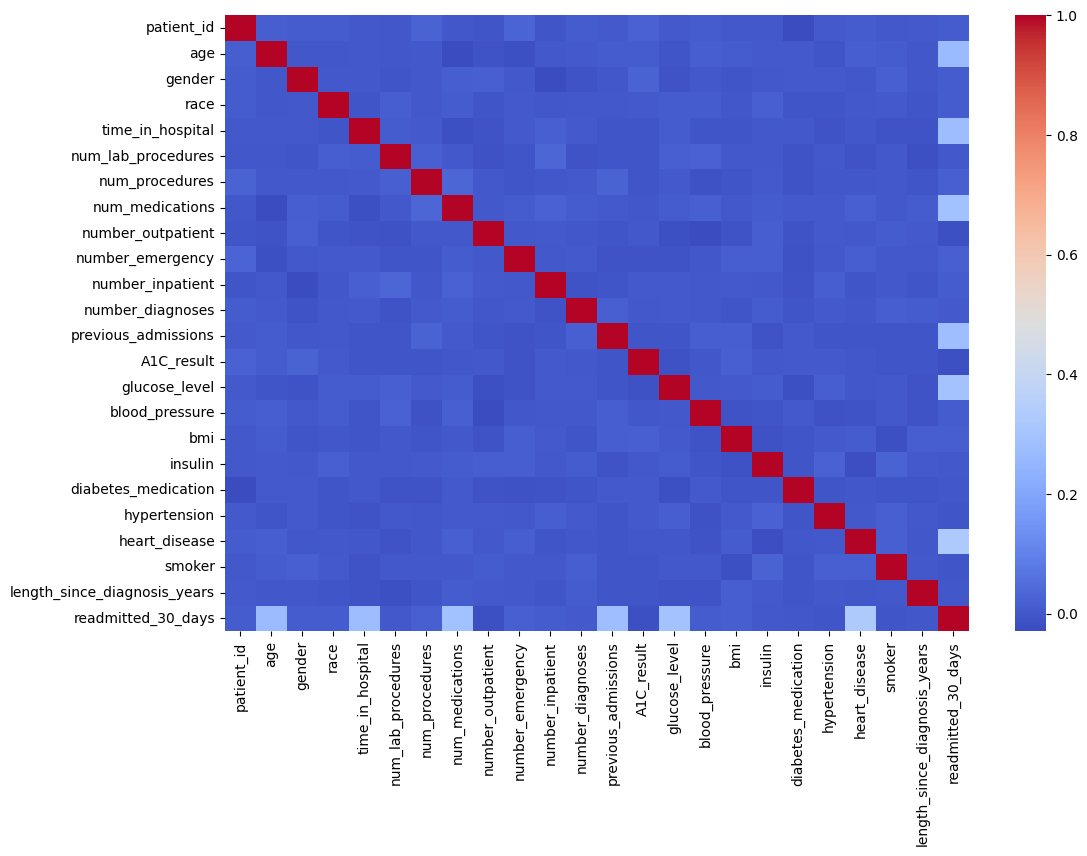

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.show()

10.Feature Selection

In [18]:
X = df.drop(
    'readmitted_30_days',
    axis=1
)

y = df['readmitted_30_days']

11.Split Data

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

12.Train Model

In [20]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

13.Prediction

In [21]:
pred = model.predict(
    X_test
)

14.Accuracy

In [22]:
accuracy_score(
    y_test,
    pred
)

0.998

15.Classification Report

In [23]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       628
           1       1.00      1.00      1.00      1372

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



16.Confusion Matrix

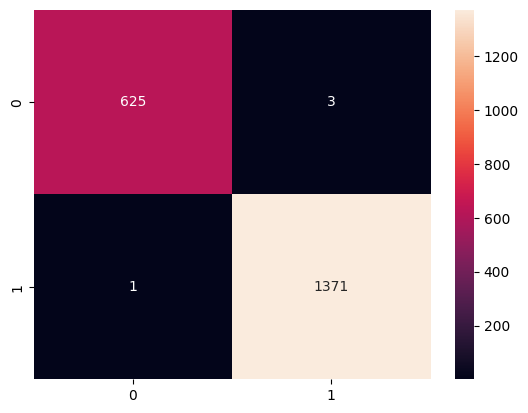

In [24]:
cm = confusion_matrix(
    y_test,
    pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

17.Feature Importance

In [25]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':
    model.feature_importances_
})

In [26]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
14,glucose_level,0.146471
7,num_medications,0.141340
4,time_in_hospital,0.128658
12,previous_admissions,0.123809
1,age,0.119874
20,heart_disease,0.109614
0,patient_id,0.025042
16,bmi,0.024331
15,blood_pressure,0.024007
5,num_lab_procedures,0.023152


18.plot

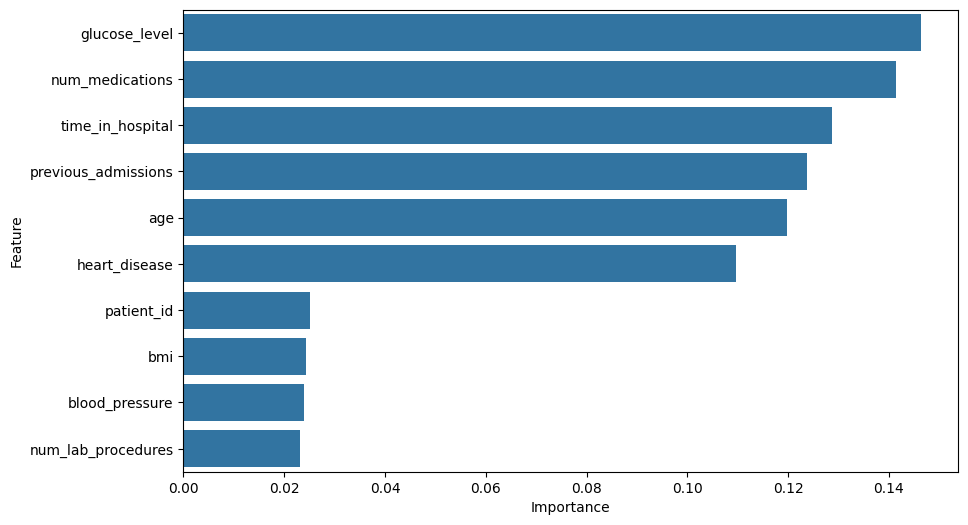

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.show()

19. Business Insights

Write findings such as:

Older patients have higher readmission risk.
High glucose levels increase readmission probability.
Previous admissions strongly affect future readmission.
Heart disease and hypertension contribute to readmission risk.
Patients with longer hospital stays are more likely to be readmi

20.Save Model

In [28]:
import joblib

joblib.dump(
    model,
    'readmission_model.pkl'
)

['readmission_model.pkl']

21.Resume Project Description

Healthcare Analytics: Predicting Hospital Readmission for Diabetes Patients

Analyzed 10,000+ diabetes patient records using Python, Pandas, and SQL.
Performed data cleaning, EDA, and feature engineering to identify key healthcare trends.
Developed a Random Forest machine learning model to predict 30-day hospital readmissions.
Achieved high predictive accuracy and generated actionable insights through data visualization and reporting.
Tools Used: Python, Google Colab, Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn, SQL.